## Gasoline Retail Price vs Quantity Sold
#### Prepared by Thang Hang

In [1]:
#!pip install pingouin

In [2]:
import time
import numpy
import pingouin as pg
import scipy
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Hypothesis and the source of the data
1. The hypothesis of this project is whether there is the same correlation from retail price to quantity sold when retail price has been increased or decreased for each product that is compared to each product of the population. Two samples of regular product and premium product are taken from the population.
2. The file,"The_site_data_2," is assumed the interested population of the two products. It is retail gasoline sales after 12/31/2020 for a gas station. The pricing information of competitors of the site should be found through the second file,"Competitor."

In [3]:
url ='https://raw.githubusercontent.com/PP53212/College/main/The_site_data_2.csv'
df1 = pd.read_csv(url,on_bad_lines='skip')

In [4]:
url2 ='https://raw.githubusercontent.com/PP53212/College/main/Competitor.csv'
df2 = pd.read_csv(url2,on_bad_lines='skip')

### 1.Regular product analysis

In [5]:
regular = df1[df1['Account'] == '1Regular']

In [6]:
pg.corr(regular['RetailPrice'],regular['SalesUnits'])

,n,r,CI95%,p-val,BF10,power
pearson,431,0.15548,"[0.06, 0.25]",0.001203,11.212,0.900839


Based on Pearson’s correlation coefficient, there is a weak positive corelation of the two variables in the population of the regular product as correlation coefficient (r) for the product is low.

Text(0.5, 1, 'Linear correlation for the regular product')

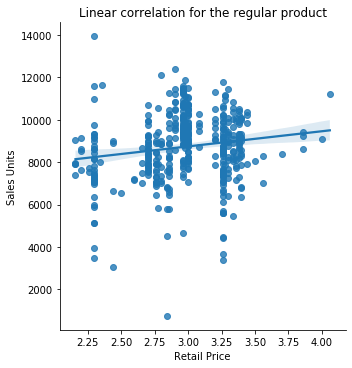

In [7]:
sns.lmplot(x = 'RetailPrice', y ='SalesUnits', data = regular) 
ax = plt.gca()
ax.set_xlabel("Retail Price")
ax.set_ylabel("Sales Units")
ax.set_title("Linear correlation for the regular product")

elapsed: 0.04154801368713379 seconds


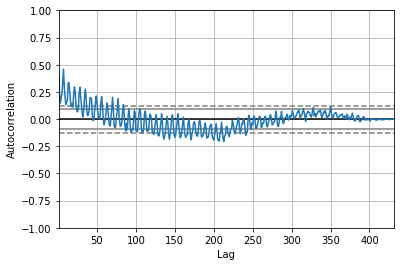

In [8]:
start_time=time.time()
pd.plotting.autocorrelation_plot(regular['SalesUnits']);
print('elapsed:',time.time()-start_time,'seconds')

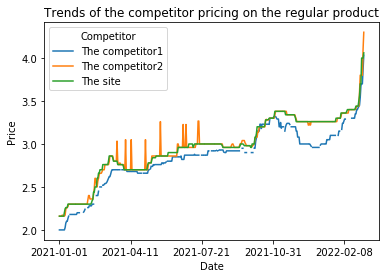

In [9]:
df2['Competitor Price'].astype(float)
regular_com_price = df2[df2['CompetitorProduct'] == '1Regular']
filt3=regular_com_price.pivot_table(index ='CompetitorDate', columns='Competitor', values='Competitor Price',aggfunc= 'mean')
filt3.plot(kind='line',
            xlabel='Date',
            ylabel='Price',
            title='Trends of the competitor pricing on the regular product')
            

#### When the regular price is rising

In [10]:
regular_s1 =regular[regular['BusDate'].between('2021-06-03','2021-07-04')]

In [11]:
pg.corr(regular_s1['RetailPrice'],regular_s1['SalesUnits']).round(2)

,n,r,CI95%,p-val,BF10,power
pearson,32,-0.28,"[-0.57, 0.08]",0.12,0.694,0.35


In [12]:
pg.ttest(regular_s1['RetailPrice'], regular_s1['SalesUnits'], paired=True).round(2)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-53.07,31,two-sided,0.0,"[-10361.59, -9594.65]",13.27,2.989e+28,1.0


Through T-test, the P-value is smaller than the significance level (α =0.05), we are not accept the null hypothesis in favor of the alternative. we conclude that there is a negative relationship between retail price and quantity sold in the population when the regular price is rising.

Text(0.5, 1, 'Linear correlation when the regular price is rising')

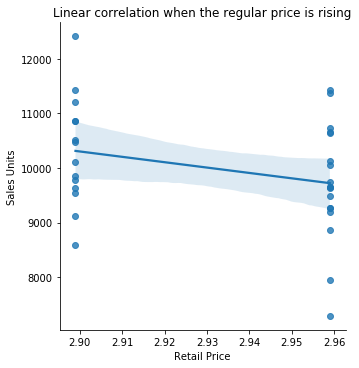

In [13]:
sns.lmplot(x = 'RetailPrice', y ='SalesUnits', data = regular_s1) 
ax = plt.gca()
ax.set_xlabel("Retail Price")
ax.set_ylabel("Sales Units")
ax.set_title("Linear correlation when the regular price is rising")

elapsed: 0.044471025466918945 seconds


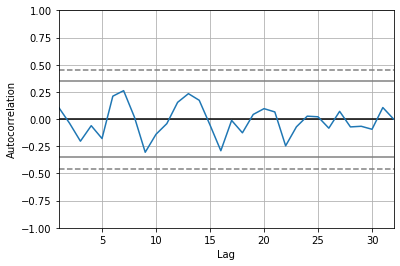

In [14]:
start_time=time.time()
pd.plotting.autocorrelation_plot(regular_s1['SalesUnits']);
print('elapsed:',time.time()-start_time,'seconds')

(array([-5.,  0.,  5., 10., 15., 20., 25., 30., 35.]),
 <a list of 9 Text xticklabel objects>)

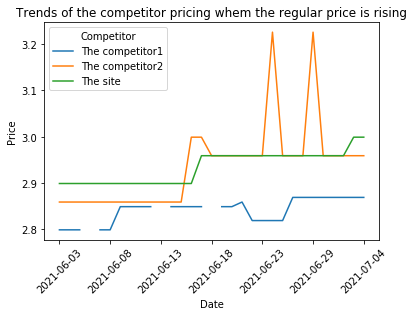

In [15]:
df2['Competitor Price'].astype(float)
regular_com_price = df2[df2['CompetitorProduct'] == '1Regular']
regular_com_price_s1= regular_com_price[regular_com_price['CompetitorDate'].between('2021-06-03','2021-07-04')]
filt1 = regular_com_price_s1.pivot_table(index ='CompetitorDate', columns='Competitor', values='Competitor Price',aggfunc= 'mean')
filt1.plot(kind='line', xlabel='Date', ylabel='Price', title='Trends of the competitor pricing whem the regular price is rising')
plt.xticks(rotation = 45)

#### When regular price is dropping

In [16]:
regular_s2 =regular[regular['BusDate'].between('2021-11-02','2021-12-04')]

In [17]:
pg.corr(regular_s2['RetailPrice'],regular_s2['SalesUnits'])

,n,r,CI95%,p-val,BF10,power
pearson,33,-0.071997,"[-0.41, 0.28]",0.690509,0.234,0.068061


In [18]:
pg.ttest(regular_s2['RetailPrice'], regular_s2['SalesUnits'], paired=True).round(2)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-47.84,32,two-sided,0.0,"[-9524.22, -8746.22]",11.78,7.217e+27,1.0


Through T-test, the P-value is smaller than the significance level (α =0.05), we are not accept the null hypothesis in favor of the alternative. we conclude that there is a negative relationship between retail price and quantity sold in the population when the regular price is dropping.

Text(0.5, 1, 'Linear correlation when the regular price is dropping')

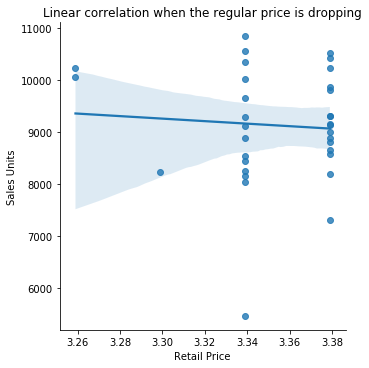

In [19]:
sns.lmplot(x = 'RetailPrice', y ='SalesUnits', data = regular_s2) 
ax = plt.gca()
ax.set_xlabel("Retail Price")
ax.set_ylabel("Sales Units")
ax.set_title("Linear correlation when the regular price is dropping")

elapsed: 0.03172802925109863 seconds


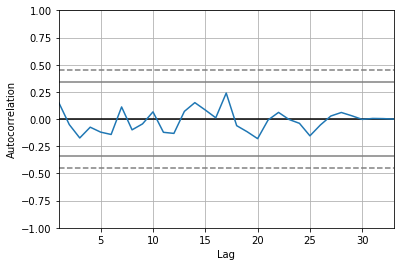

In [20]:
start_time=time.time()
pd.plotting.autocorrelation_plot(regular_s2['SalesUnits']);
print('elapsed:',time.time()-start_time,'seconds')

(array([-5.,  0.,  5., 10., 15., 20., 25., 30., 35.]),
 <a list of 9 Text xticklabel objects>)

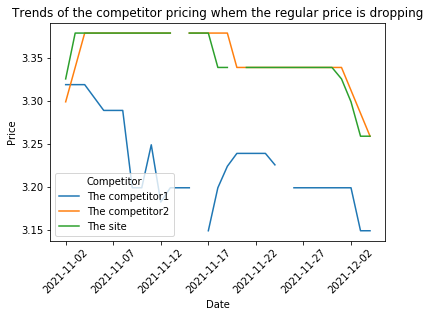

In [21]:
regular_com_price_s2= regular_com_price[regular_com_price['CompetitorDate'].between('2021-11-02','2021-12-04')]
filt2 = regular_com_price_s2.pivot_table(index ='CompetitorDate', columns='Competitor', values='Competitor Price',aggfunc= 'mean')
filt2.plot(kind='line', xlabel='Date', ylabel='Price',title='Trends of the competitor pricing whem the regular price is dropping')
plt.xticks(rotation = 45)

### 2. Premium product analysis

In [22]:
premium = df1[df1['Account'] == '3Premium']
pg.corr(premium['RetailPrice'],premium['SalesUnits'])

,n,r,CI95%,p-val,BF10,power
pearson,431,0.109113,"[0.01, 0.2]",0.023486,0.778,0.621243


Based on Pearson’s correlation coefficient, there is a weak positive corelation of the two variables in the population of the premium product as correlation coefficient (r) for the product is low.

Text(0.5, 1, 'Linear correlation for the premium product')

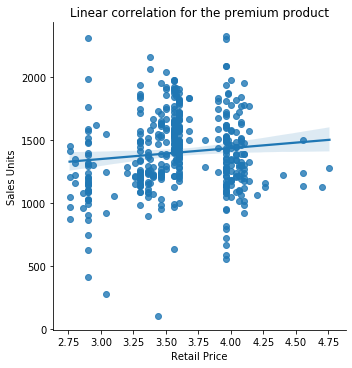

In [23]:
sns.lmplot(x = 'RetailPrice', y ='SalesUnits', data = premium) 
ax = plt.gca()
ax.set_xlabel("Retail Price")
ax.set_ylabel("Sales Units")
ax.set_title("Linear correlation for the premium product")

elapsed: 0.05244708061218262 seconds


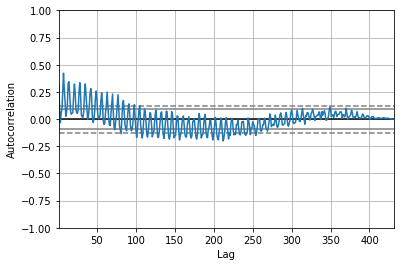

In [24]:
start_time=time.time()
pd.plotting.autocorrelation_plot(premium['SalesUnits']);
print('elapsed:',time.time()-start_time,'seconds')

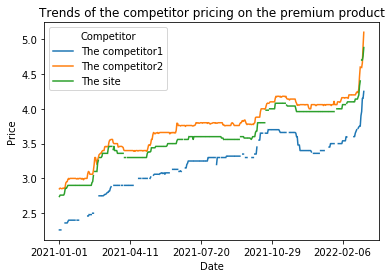

In [25]:
premium_com_price = df2[df2['CompetitorProduct'] == '3Premium']
filt3=premium_com_price.pivot_table(index ='CompetitorDate', columns='Competitor', values='Competitor Price',aggfunc= 'mean')
filt3.plot(kind='line',
            xlabel='Date',
            ylabel='Price',
            title='Trends of the competitor pricing on the premium product')

#### When the premium price is rising

In [26]:
premium_s1 =premium[premium['BusDate'].between('2021-06-03','2021-07-04')]
pg.corr(premium_s1['RetailPrice'],premium_s1['SalesUnits'])

,n,r,CI95%,p-val,BF10,power
pearson,32,-0.301979,"[-0.59, 0.05]",0.093004,0.849,0.397805


In [27]:
pg.ttest(premium_s1['RetailPrice'], premium_s1['SalesUnits'], paired=True).round(2)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-40.72,31,two-sided,0.0,"[-1636.87, -1480.72]",10.18,1.189e+25,1.0


Through T-test, the P-value is smaller than the significance level (α =0.05), we are not accept the null hypothesis in favor of the alternative. we conclude that there is a negative relationship between retail price and quantity sold in the population when the premium price is rising.

Text(0.5, 1, 'Linear correlation when the premium price is rising')

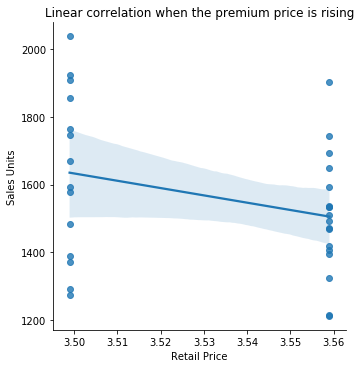

In [28]:
sns.lmplot(x = 'RetailPrice', y ='SalesUnits', data = premium_s1) 
ax = plt.gca()
ax.set_xlabel("Retail Price")
ax.set_ylabel("Sales Units")
ax.set_title("Linear correlation when the premium price is rising")

elapsed: 0.03702497482299805 seconds


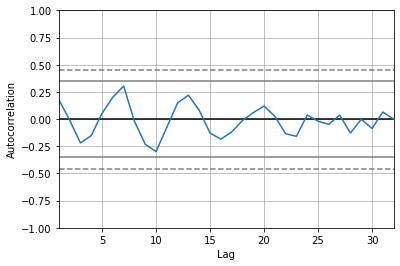

In [29]:
start_time=time.time()
pd.plotting.autocorrelation_plot(premium_s1['SalesUnits']);
print('elapsed:',time.time()-start_time,'seconds')

(array([-5.,  0.,  5., 10., 15., 20., 25., 30., 35.]),
 <a list of 9 Text xticklabel objects>)

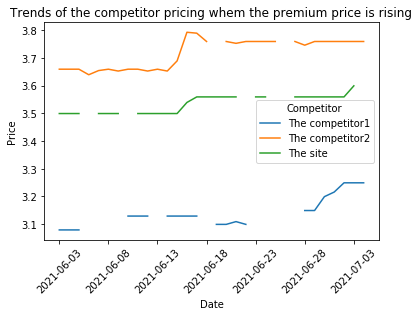

In [30]:
premium_com_price_s1= premium_com_price[premium_com_price['CompetitorDate'].between('2021-06-03','2021-07-04')]
filt4 = premium_com_price_s1.pivot_table(index ='CompetitorDate', columns='Competitor', values='Competitor Price',aggfunc= 'mean')
filt4.plot(kind='line', xlabel='Date', ylabel='Price',title='Trends of the competitor pricing whem the premium price is rising')
plt.xticks(rotation = 45)

#### When the premium price is dropping

In [31]:
premium_s2 =premium[premium['BusDate'].between('2021-11-02','2021-12-04')]
pg.corr(premium_s2['RetailPrice'],premium_s2['SalesUnits'])

,n,r,CI95%,p-val,BF10,power
pearson,33,-0.068935,"[-0.4, 0.28]",0.703067,0.232,0.066498


In [32]:
pg.ttest(premium_s2['RetailPrice'], premium_s2['SalesUnits'], paired=True).round(2)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-37.75,32,two-sided,0.0,"[-1500.46, -1346.83]",9.29,5.351e+24,1.0


Through T-test, the P-value is smaller than the significance level (α =0.05), we are not accept the null hypothesis in favor of the alternative. we conclude that there is a negative relationship between retail price and quantity sold in the population when the premium price is dropping.

Text(0.5, 1, 'Linear correlation when the premium price is dropping')

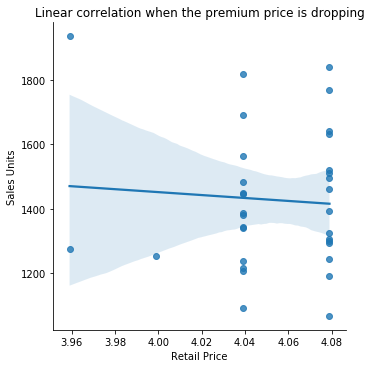

In [33]:
sns.lmplot(x = 'RetailPrice', y ='SalesUnits', data = premium_s2) 
ax = plt.gca()
ax.set_xlabel("Retail Price")
ax.set_ylabel("Sales Units")
ax.set_title("Linear correlation when the premium price is dropping")

elapsed: 0.1272430419921875 seconds


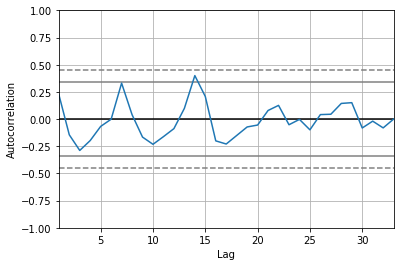

In [34]:
start_time=time.time()
pd.plotting.autocorrelation_plot(premium_s2['SalesUnits']);
print('elapsed:',time.time()-start_time,'seconds')

(array([-5.,  0.,  5., 10., 15., 20., 25., 30., 35.]),
 <a list of 9 Text xticklabel objects>)

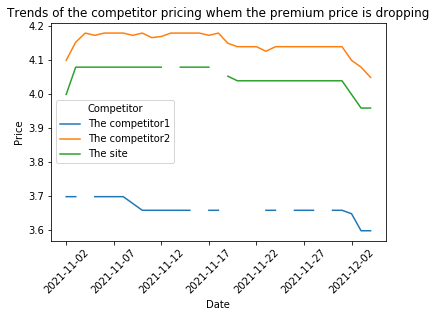

In [35]:
premium_com_price_s2= premium_com_price[premium_com_price['CompetitorDate'].between('2021-11-02','2021-12-04')]
filt5 = premium_com_price_s2.pivot_table(index ='CompetitorDate', columns='Competitor', values='Competitor Price',aggfunc= 'mean')
filt5.plot(kind='line', xlabel='Date', ylabel='Price',title='Trends of the competitor pricing whem the premium price is dropping')
plt.xticks(rotation = 45)